# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import os
import sys
import warnings
from scipy.stats import zscore
from sklearn.cluster import DBSCAN

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [2]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # Select the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

In [3]:
def correlation_matrix(data, threshold, x, y):

    """
    correlation_matrix plots a Pearson correlation matrix heatmap for numerical features in a dataset,
    displaying correlation values only when their absolute value exceeds a given
    threshold. We used it to analyse the correlation between our numerical features in EDA.

    Parameters:
    data : Input dataset containing numerical variables.
    
    threshold : Minimum absolute correlation value required for a cell to be annotated

    Returns: None, displays a correlation heatmap.
    """
    
    corr = data.corr(method="pearson")
    corr = corr.round(2)

    mask_annot = np.absolute(corr.values) >= threshold

    annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 

    fig = plt.figure(figsize=(x, y))

    # Plotting the heatmap of the correlation matrix
    sns.heatmap(data=corr, 
                annot=annot, # Specifing custom annotation
                fmt='s', # The annotation matrix now has strings, so we need to explicitly say this
                vmin=-1, vmax=1, 
                center=0,
                square=True, # Make each cell square-shaped
                linewidths=.5, # Adding lines between cells
                cmap='PiYG' # Diverging color map
                )

    plt.show()


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [4]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [5]:
len(people)

16695

In [6]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16695 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16695 non-null  float64
 1   Customer Lifetime Value         16695 non-null  float64
 2   EnrollmentType                  16695 non-null  int64  
 3   rejoined_program                16695 non-null  int64  
 4   Days_in_prog                    16695 non-null  float64
 5   Cancelled_program               16695 non-null  int64  
 6   Enrollment_year                 16695 non-null  int64  
 7   Enrollment_month                16695 non-null  int64  
 8   Location_cluster                16695 non-null  int64  
 9   TotalFlights                    16695 non-null  float64
 10  TotalDistance                   16695 non-null  float64
 11  TotalPointsAccumulated          16695 non-null  float64
 12  TotalPointsRedeemed            

In [7]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [8]:
people1 = people.copy()

In [9]:
for column in people1.columns:
   if column.startswith('Total_Spend_Month_'):
       people1[column] = np.sqrt(people1[column])

In [10]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

## <h2 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 3: VALUE-BASED SEGMENTATION</h2>

Prepare the data

### Perspective 2 — Engagement Features

In this perspective, we analyze the **level of engagement** customers have with the loyalty program.  
Instead of focusing only on *who they are*, we start looking at **how they interact with the program over time**.

We selected the following variables:

```python
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]


In [11]:
# Perspective 2 — Engagement Features
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]

### Preparing the Engagement Dataset

Now that we defined the engagement variables, we extract them from the main dataset to build a dedicated clustering view.

```python
customer_engagement = people[engagement_features].copy()


In [12]:
# Prepare data
customer_engagement = people[engagement_features].copy()

In [13]:
# First look at distributions
customer_engagement.describe()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
count,16695.000000,16695.000000,16695.000000,16695.000000,16695.000000
mean,1091.741659,92.816183,0.131710,0.231335,0.277600
std,743.947134,286.512522,0.075579,0.133497,0.336624
min,0.000000,1.018397,0.000000,0.000000,0.000000
25%,360.500000,1.018397,0.066347,0.161069,0.000000
50%,1014.000000,1.018397,0.151050,0.234052,0.214605
75%,1744.000000,2.003942,0.188311,0.304202,0.417202
max,2465.000000,999.000000,0.492603,1.052632,7.674566


## Correlation Matrix

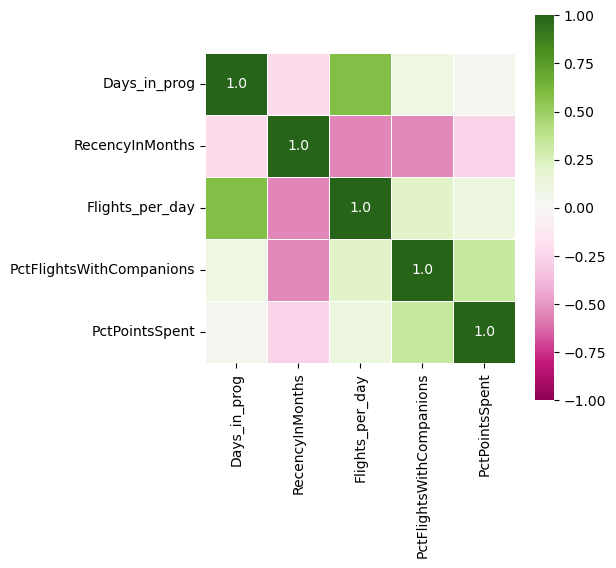

In [14]:
correlation_matrix(customer_engagement, 0.7, 5, 5)

Feature selection check — Engagement perspective

To validate our feature choice, we computed a Pearson correlation matrix.
The engagement variables show **only moderate correlations** and no values close to ±1, meaning:

* none of the variables are redundant or simple duplicates,
* each feature contributes distinct information about customer engagement.

Therefore, the selected features
**(Days_in_prog, Recency, Flights_per_day, Companion % and Points %)**
are appropriate for clustering and we keep all of them.


In [15]:
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")
mm_scaler = MinMaxScaler().set_output(transform="pandas")

customer_engagement_st = st_scaler.fit_transform(customer_engagement)
customer_engagement_rb = rb_scaler.fit_transform(customer_engagement)
customer_engagement_mm = mm_scaler.fit_transform(customer_engagement)


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

Choosing the number of clusters (Engagement perspective)

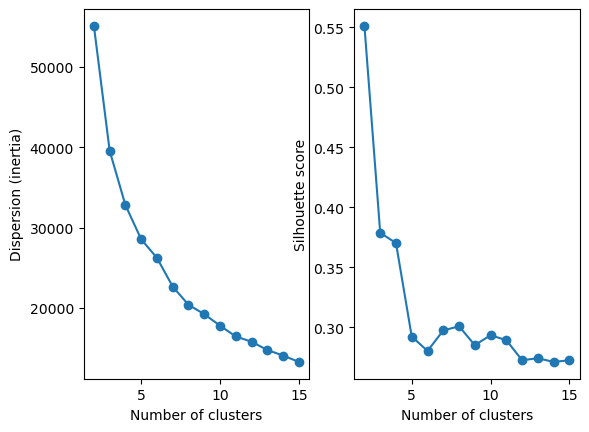

In [16]:
plot_inertia_and_silhouette(customer_engagement_st)

From the inertia (elbow) and silhouette plots, we see:

- A strong improvement from **K = 2 → 3**
- A smaller but meaningful gain at **K = 4**
- After K ≥ 5, inertia decreases slowly and silhouette becomes unstable

To avoid over-fragmenting the data while keeping clusters interpretable,  
we test **K = 3 and K = 4** and compare their business meaning.

In [17]:
kmeans_st_scl_3 = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster3'] = kmeans_st_scl_3.predict(customer_engagement_st)

kmeans_st_scl_4 = KMeans(n_clusters=4, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster4'] = kmeans_st_scl_4.predict(customer_engagement_st)


In [18]:
tmp = customer_engagement_st.copy()
tmp['st_scaled_km_cluster3'] = people['st_scaled_km_cluster3']

groupby_mean(
    tmp,
    'st_scaled_km_cluster3',
    n_features=5
)


st_scaled_km_cluster3,0,1,2
Days_in_prog,-0.963847,-0.684904,0.629915
RecencyInMonths,-0.312415,3.162902,-0.318140
Flights_per_day,-0.728468,-1.716407,0.661063
PctFlightsWithCompanions,0.242918,-1.709807,0.131716
PctPointsSpent,0.112430,-0.816257,0.064805


In [19]:
tmp = customer_engagement_st.copy()
tmp['st_scaled_km_cluster4'] = people['st_scaled_km_cluster4']

groupby_mean(
    tmp,
    'st_scaled_km_cluster4',
    n_features=5
)


st_scaled_km_cluster4,0,1,2,3
Days_in_prog,-0.723876,-0.684904,-0.936046,0.669772
RecencyInMonths,-0.313051,3.162902,-0.312675,-0.318246
Flights_per_day,-0.585919,-1.716407,-0.638828,0.676160
PctFlightsWithCompanions,1.173868,-1.709807,-0.079024,0.122630
PctPointsSpent,1.806072,-0.816257,-0.412008,0.028545


Choosing K for Engagement Clustering in Standard Scaling (K-Means)

We compared K = 3 and K = 4 using the standardized engagement features.

K = 3

Captures the main structure, but mixes different types of low-engagement customers together.

K = 4

Separates the customers more clearly into:

dormant / almost inactive

low-engagement

moderate users

highly engaged members

Decision

K = 4 gives clearer, more interpretable behavioral groups, so we continue with this solution.

### Hierarchichal - Ward

In [20]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_st.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


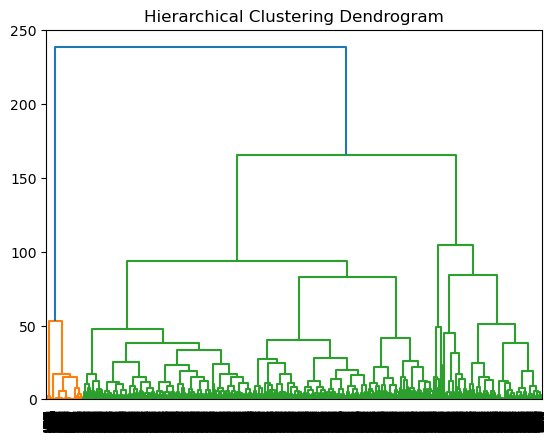

In [21]:
plot_dendrogram(customer_engagement_st, 'ward')

Hierarchical clustering — testing Ward solutions (k = 2, 3, 4)

With the dendrogram and silhouette trends, we focused on a small set of
promising cluster solutions. Ward’s method suggested that the main
structure emerges between **2 and 4 groups**, so we test those values to
compare stability and interpretability.

We now compute hierarchical clustering for:

* **k = 2** → coarse segmentation
* **k = 3** → clearer behavioral separation
* **k = 4** → more granular, but still interpretable

The goal is to choose the smallest *k* that still produces meaningful,
well-separated engagement profiles.


In [22]:
# Hierarchical clustering (Ward) on engagement features
for k in [2, 3, 4]:
    people[f'st_scaled_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_st)


In [23]:
for k in [2, 3, 4]:
    tmp = customer_engagement_st[engagement_features].copy()
    tmp[f'st_scaled_ward_cluster{k}'] = people[f'st_scaled_ward_cluster{k}']

    print(f"\nWard clustering – k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st_scaled_ward_cluster{k}',
            n_features=5
        )
    )



Ward clustering – k = 2


st_scaled_ward_cluster2,0,1
Days_in_prog,0.068454,-0.684904
RecencyInMonths,-0.316123,3.162902
Flights_per_day,0.171550,-1.716407
PctFlightsWithCompanions,0.170891,-1.709807
PctPointsSpent,0.081583,-0.816257



Ward clustering – k = 3


st_scaled_ward_cluster3,0,1,2
Days_in_prog,-1.066011,-0.684904,0.420172
RecencyInMonths,-0.311044,3.162902,-0.317698
Flights_per_day,-1.098104,-1.716407,0.565180
PctFlightsWithCompanions,0.210966,-1.709807,0.158466
PctPointsSpent,0.143130,-0.816257,0.062501



Ward clustering – k = 4


st_scaled_ward_cluster4,0,1,2,3
Days_in_prog,0.420172,-0.684904,-1.056103,-1.170168
RecencyInMonths,-0.317698,3.162902,-0.311091,-0.310548
Flights_per_day,0.565180,-1.716407,-1.081053,-1.277357
PctFlightsWithCompanions,0.158466,-1.709807,0.107176,1.302097
PctPointsSpent,0.062501,-0.816257,-0.221361,3.974966


In [24]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_st.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


Ward clustering — choosing k

We evaluated k = 2, 3, 4.

k = 2 → too coarse (mainly low vs. high engagement).

k = 4 → adds complexity without clearly distinct new patterns.

k = 3 → provides the cleanest, most interpretable separation.

We therefore select k = 3.

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

In [25]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


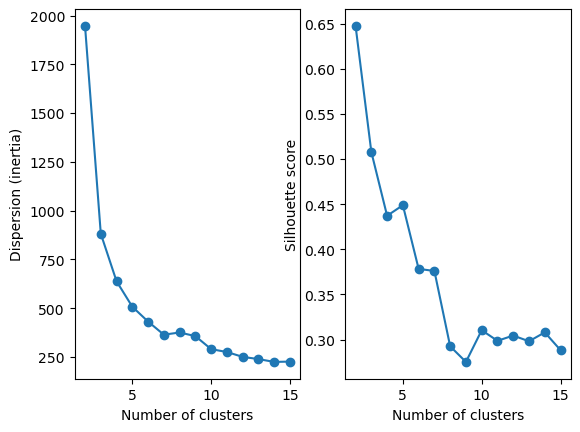

In [26]:
plot_inertia_and_silhouette(customer_engagement_mm)

In [27]:
# K-Means on engagement features (Min-Max Scaled)

kmeans_mm_3 = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster3'] = kmeans_mm_3.predict(customer_engagement_mm)

kmeans_mm_4 = KMeans(n_clusters=4, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster4'] = kmeans_mm_4.predict(customer_engagement_mm)

kmeans_mm_5 = KMeans(n_clusters=5, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster5'] = kmeans_mm_5.predict(customer_engagement_mm)

kmeans_mm_6 = KMeans(n_clusters=6, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster6'] = kmeans_mm_6.predict(customer_engagement_mm)


In [28]:
for k in [3, 4, 5, 6]:
    tmp = customer_engagement_mm.copy()
    tmp[f'mm_scaled_km_cluster{k}'] = people[f'mm_scaled_km_cluster{k}']

    print(f"\nK-means MinMax — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'mm_scaled_km_cluster{k}',
            n_features=5
        )
    )



K-means MinMax — k = 3


mm_scaled_km_cluster3,0,1,2
Days_in_prog,0.209127,0.236197,0.719667
RecencyInMonths,0.001720,1.000000,0.000736
Flights_per_day,0.223251,0.004040,0.364607
PctFlightsWithCompanions,0.244816,0.002934,0.238042
PctPointsSpent,0.040359,0.000370,0.039136



K-means MinMax — k = 4


mm_scaled_km_cluster4,0,1,2,3
Days_in_prog,0.126187,0.236197,0.806858,0.433977
RecencyInMonths,0.002209,1.000000,0.000661,0.000892
Flights_per_day,0.147547,0.004040,0.362191,0.360200
PctFlightsWithCompanions,0.247522,0.002934,0.239738,0.237538
PctPointsSpent,0.040828,0.000370,0.039141,0.039361



K-means MinMax — k = 5


mm_scaled_km_cluster5,0,1,2,3,4
Days_in_prog,0.299715,0.236197,0.853209,0.573107,0.112773
RecencyInMonths,0.000776,1.000000,0.000619,0.000944,0.002552
Flights_per_day,0.347324,0.004040,0.362692,0.359453,0.108466
PctFlightsWithCompanions,0.234204,0.002934,0.238906,0.239654,0.252495
PctPointsSpent,0.038938,0.000370,0.038979,0.039470,0.041560



K-means MinMax — k = 6


mm_scaled_km_cluster6,0,1,2,3,4,5
Days_in_prog,0.304141,0.236197,0.854838,0.577167,0.116371,0.112118
RecencyInMonths,0.000758,1.000000,0.000622,0.000917,0.002487,0.002713
Flights_per_day,0.349845,0.004040,0.362754,0.359427,0.119396,0.092562
PctFlightsWithCompanions,0.236937,0.002934,0.239004,0.239058,0.164024,0.448269
PctPointsSpent,0.039179,0.000370,0.038962,0.039413,0.031730,0.063498


Choosing k for K-Means (Min-Max scaled)

Across the Min-Max scaled solutions (k = 3, 4, 5, 6), cluster structures are quite similar:
clusters mainly differ by engagement intensity (tenure, flights, points spent).

k = 3 already separates: low, medium, and high engagement.

k = 4 adds only a minor split (medium users split into two very similar groups).

k = 5–6 produce small, overly specific clusters without new business meaning.

We therefore keep k = 3 for the Min-Max scaling, since it gives the clearest, interpretable segmentation with minimal redundancy.

### Hierarchichal - Ward

In [29]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


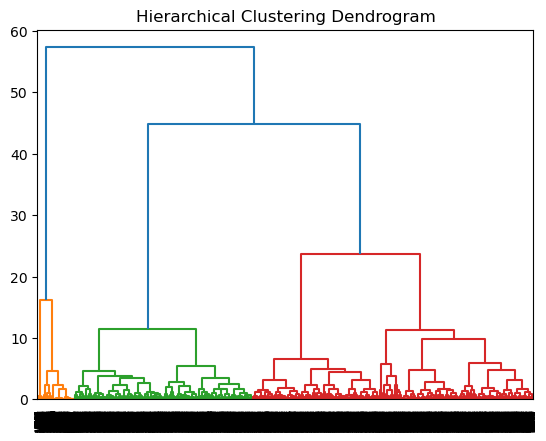

In [30]:
plot_dendrogram(customer_engagement_mm, 'ward')

In [31]:
# Hierarchical clustering (Ward) on engagement features — Min-Max scaled
for k in [2, 3, 4, 8]:
    people[f'mm_scaled_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_mm)

In [32]:
# Inspect cluster profiles 
for k in [2, 3, 4, 8]:
    tmp = customer_engagement_mm.copy()
    tmp[f'mm_scaled_ward_cluster{k}'] = people[f'mm_scaled_ward_cluster{k}']

    print(f"\nWard (Min-Max) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'mm_scaled_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Min-Max) — k = 2


mm_scaled_ward_cluster2,0,1
Days_in_prog,0.463556,0.236197
RecencyInMonths,0.001230,1.000000
Flights_per_day,0.293696,0.004040
PctFlightsWithCompanions,0.241440,0.002934
PctPointsSpent,0.039750,0.000370



Ward (Min-Max) — k = 3


mm_scaled_ward_cluster3,0,1,2
Days_in_prog,0.263204,0.236197,0.778183
RecencyInMonths,0.001552,1.000000,0.000723
Flights_per_day,0.249326,0.004040,0.363373
PctFlightsWithCompanions,0.242250,0.002934,0.240168
PctPointsSpent,0.040126,0.000370,0.039158



Ward (Min-Max) — k = 4


mm_scaled_ward_cluster4,0,1,2,3
Days_in_prog,0.236197,0.134805,0.778183,0.418494
RecencyInMonths,1.000000,0.002145,0.000723,0.000835
Flights_per_day,0.004040,0.156268,0.363373,0.361874
PctFlightsWithCompanions,0.002934,0.247490,0.240168,0.235913
PctPointsSpent,0.000370,0.040813,0.039158,0.039296



Ward (Min-Max) — k = 8


mm_scaled_ward_cluster8,0,1,2,3,4,5,6,7
Days_in_prog,0.418494,0.178833,0.077354,0.883080,0.942711,0.115080,0.672965,0.099207
RecencyInMonths,0.000835,0.001414,0.002931,0.000628,1.000000,1.000000,0.000819,0.002799
Flights_per_day,0.361874,0.241840,0.050869,0.362234,0.000000,0.004733,0.364516,0.084727
PctFlightsWithCompanions,0.235913,0.258116,0.492167,0.248097,0.000000,0.003437,0.232214,0.141774
PctPointsSpent,0.039296,0.041368,0.084667,0.040556,0.000000,0.000433,0.037756,0.023619


In [33]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


Ward clustering (Min-Max) — choosing k

For Ward with Min-Max scaling, the structures are:

k = 2 → very coarse split (recent vs. non-recent customers)

k = 3–4 → clusters become interpretable and behaviorally distinct
(tenure vs. recency vs. flight intensity)

k = 8 → mostly fragments existing groups without adding clear insight

We retain k = 3 (and consider k = 4 as an alternative) because these solutions:

separate customers along meaningful engagement dimensions,

are stable, avoid over-fragmentation.

k = 8 is more granular, but does not translate into clearer business actions.

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

### Testing Different Values of K (Behavioral / Engagement Clustering)

We now evaluate how many clusters make sense for the *engagement* dimension.

First, we visualized inertia and silhouette scores:

```python
plot_inertia_and_silhouette(customer_engagement_rb)


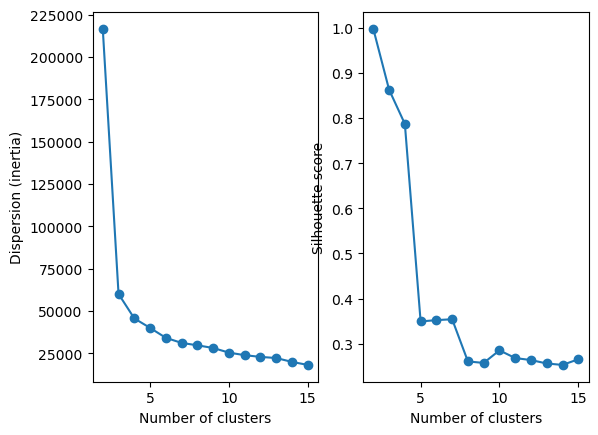

In [34]:
plot_inertia_and_silhouette(customer_engagement_rb)

### Running K-Means with Multiple K Values

To understand how the data behaves under different segmentation granularities,
we run K-Means repeatedly using several candidate values for **K**.


In [35]:
for k in [3, 4, 5]:
    kmeans_rb_scl = KMeans(n_clusters=k, random_state=42).fit(customer_engagement_rb)
    people[f"rb_scaled_km_cluster{k}"] = kmeans_rb_scl.predict(customer_engagement_rb)


In [36]:
# Inspect cluster profiles
for k in [3, 4, 5]:
    tmp = customer_engagement_rb.copy()
    tmp[f'rb_scaled_km_cluster{k}'] = people[f'rb_scaled_km_cluster{k}']

    print(f"\nK-means Robust — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb_scaled_km_cluster{k}',
            n_features=5
        )
    )


K-means Robust — k = 3


rb_scaled_km_cluster3,0,1,2
Days_in_prog,-0.263626,-0.312089,0.111487
RecencyInMonths,15.342647,1012.618667,0.514403
Flights_per_day,-0.626750,-1.222169,-0.022488
PctFlightsWithCompanions,0.191416,-1.613626,0.137750
PctPointsSpent,0.189872,-0.507593,0.218215



K-means Robust — k = 4


rb_scaled_km_cluster4,0,1,2,3
Days_in_prog,-0.263587,-0.312089,0.155456,-0.000395
RecencyInMonths,15.848021,1012.618667,0.079535,1.666445
Flights_per_day,-0.638496,-1.222169,0.040795,-0.182301
PctFlightsWithCompanions,0.199229,-1.613626,0.251370,-0.140715
PctPointsSpent,0.189541,-0.507593,0.297542,0.023991



K-means Robust — k = 5


rb_scaled_km_cluster5,0,1,2,3,4
Days_in_prog,-0.230979,-0.312089,0.163289,-0.003285,-0.281758
RecencyInMonths,10.043053,1012.618667,0.076042,1.396617,19.136633
Flights_per_day,-0.436262,-1.222169,0.049603,-0.181957,-0.802430
PctFlightsWithCompanions,0.127471,-1.613626,0.264400,-0.160292,0.235818
PctPointsSpent,0.205553,-0.507593,0.308898,0.004045,0.176172


Choosing the number of clusters (Engagement perspective)

To decide the best value of K, we tested K-Means with K = 3, 4 and 5 using the engagement features.
Across all values, we consistently observed one clear segment of non-active customers (very high recency, almost no flights, almost no points spent). This shows that the clustering is capturing a real pattern in the data.

However, the structure of the remaining clusters changed:

K = 3 was too coarse — active customers with different engagement levels were mixed together.

K = 5 started to over-segment the data, creating clusters that were very similar to each other and harder to interpret.

K = 4 provided the best balance: it separates customers into four intuitive behavioral groups (inactive, low, moderate and high engagement) while remaining simple to explain from a business perspective.

For this reason, we continue with K = 4.

### Hierarchichal - Ward

### Hierarchical Clustering — Dendrogram (Ward Linkage)

To complement the K-Means analysis, we also explore the structure of the data
using **hierarchical clustering**.

In [37]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


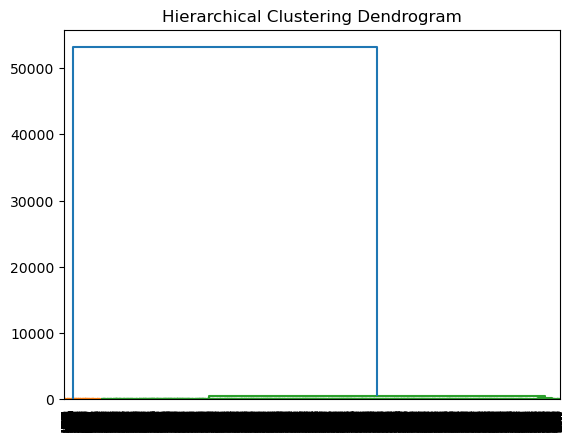

In [38]:
plot_dendrogram(customer_engagement_rb, 'ward')

### Using the Dendrogram to Select Candidate Cluster Counts

After inspecting the dendrogram generated with Ward linkage, we observed a few
large vertical jumps, suggesting that the data may naturally separate into a
small number of groups.

To evaluate those possibilities more systematically, we tested hierarchical
clustering with different values of \(k\):

In [39]:
for k in [3, 4, 5, 6]:
    people[f"rb_scaled_ward_cluster{k}"] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_rb)

    print(f"K = {k}")
    display(groupby_mean(people, f"rb_scaled_ward_cluster{k}").head(10))


K = 3


rb_scaled_ward_cluster3,0,1,2
Income,36976.672566,37933.992749,37809.953412
Customer Lifetime Value,7694.709934,8329.786427,7943.717072
EnrollmentType,0.013274,0.027686,0.075872
rejoined_program,0.002212,0.014502,0.011910
Days_in_prog,686.201327,582.224786,1171.575312
Cancelled_program,0.892699,0.615689,0.021227
Enrollment_year,2018.579646,2017.800264,2018.277918
Enrollment_month,6.696903,7.259064,6.600462
Location_cluster,2.342920,2.469347,2.444234
TotalFlights,88.107633,0.000000,162.872762


K = 4


rb_scaled_ward_cluster4,0,1,2,3
Income,37809.953412,36400.591584,37442.1460,37933.992749
Customer Lifetime Value,7943.717072,7565.992525,7798.7136,8329.786427
EnrollmentType,0.075872,0.017327,0.0100,0.027686
rejoined_program,0.011910,0.000000,0.0040,0.014502
Days_in_prog,1171.575312,744.940594,638.7400,582.224786
Cancelled_program,0.021227,0.868812,0.9120,0.615689
Enrollment_year,2018.277918,2018.794554,2018.4060,2017.800264
Enrollment_month,6.600462,6.960396,6.4840,7.259064
Location_cluster,2.444234,2.311881,2.3680,2.469347
TotalFlights,162.872762,111.913119,68.8728,0.000000


K = 5


rb_scaled_ward_cluster5,0,1,2,3,4
Income,37442.1460,38119.912038,37698.986395,37933.992749,36400.591584
Customer Lifetime Value,7798.7136,7908.181151,7956.439141,8329.786427,7565.992525
EnrollmentType,0.0100,0.064576,0.079916,0.027686,0.017327
rejoined_program,0.0040,0.003455,0.014937,0.014502,0.000000
Days_in_prog,638.7400,1308.295775,1122.628580,582.224786,744.940594
Cancelled_program,0.9120,0.058995,0.007706,0.615689,0.868812
Enrollment_year,2018.4060,2017.909912,2018.409666,2017.800264,2018.794554
Enrollment_month,6.4840,6.399150,6.672534,7.259064,6.960396
Location_cluster,2.3680,2.443263,2.444582,2.469347,2.311881
TotalFlights,68.8728,174.600213,158.674265,0.000000,111.913119


K = 6


rb_scaled_ward_cluster6,0,1,2,3,4,5
Income,37698.986395,38119.912038,36123.782456,37933.992749,36400.591584,39189.744186
Customer Lifetime Value,7956.439141,7908.181151,7829.498912,8329.786427,7565.992525,7757.905163
EnrollmentType,0.079916,0.064576,0.014035,0.027686,0.017327,0.004651
rejoined_program,0.014937,0.003455,0.007018,0.014502,0.000000,0.000000
Days_in_prog,1122.628580,1308.295775,664.435088,582.224786,744.940594,604.679070
Cancelled_program,0.007706,0.058995,0.912281,0.615689,0.868812,0.911628
Enrollment_year,2018.409666,2017.909912,2018.536842,2017.800264,2018.794554,2018.232558
Enrollment_month,6.672534,6.399150,6.256140,7.259064,6.960396,6.786047
Location_cluster,2.444582,2.443263,2.298246,2.469347,2.311881,2.460465
TotalFlights,158.674265,174.600213,94.022807,0.000000,111.913119,35.534419


Using hierarchical clustering (Ward), we tested cut levels between 3 and 6 clusters. 

K = 4 produced the best structure: non-travellers were clearly separated, and the remaining customers formed intuitive engagement tiers (low, moderate, high).
Larger K values started to over-segment similar customers, while smaller K mixed distinct behaviors together.
Therefore, we selected Ward with K = 4 for the engagement perspective.

In [40]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


In [41]:
people['rb_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(customer_engagement_rb)

In [42]:
groupby_mean(people, 'rb_scaled_ward_cluster4')

rb_scaled_ward_cluster4,0,1,2,3
Income,37809.953412,36400.591584,37442.146000,37933.992749
Customer Lifetime Value,7943.717072,7565.992525,7798.713600,8329.786427
EnrollmentType,0.075872,0.017327,0.010000,0.027686
rejoined_program,0.011910,0.000000,0.004000,0.014502
Days_in_prog,1171.575312,744.940594,638.740000,582.224786
Cancelled_program,0.021227,0.868812,0.912000,0.615689
Enrollment_year,2018.277918,2018.794554,2018.406000,2017.800264
Enrollment_month,6.600462,6.960396,6.484000,7.259064
Location_cluster,2.444234,2.311881,2.368000,2.469347
TotalFlights,162.872762,111.913119,68.872800,0.000000


In [43]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


# <span style="color:#0097b2">2. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization (Perspective 1 — Profile Features)

To visually assess the structure of the clusters, we projected the engagement features to 2-D using UMAP and overlaid the labels from each candidate model.

UMAP does not influence the clustering — it only helps us inspect whether clusters appear compact and well-separated.

Across models we observed:

Some configurations created partitions that overlapped strongly, suggesting that they were forcing splits without clear behavioral meaning.

Others formed more stable, compact regions, where customers with similar engagement patterns stayed together.

The most interpretable structures appeared when using:

StandardScaler — K-Means (K = 4)

Min-Max — K-Means (K = 3)

Robust — K-Means (K = 4)

Ward Hierarchical clustering with K = 3–4 (depending on the scaler)

These solutions consistently produced clusters that map naturally to business concepts such as inactive, low, moderate, and high engagement, while avoiding unnecessary fragmentation.


In [44]:
[col for col in people.columns if "km" in col or "ward" in col]


['st_scaled_km_cluster3',
 'st_scaled_km_cluster4',
 'st_scaled_ward_cluster2',
 'st_scaled_ward_cluster3',
 'st_scaled_ward_cluster4',
 'mm_scaled_km_cluster3',
 'mm_scaled_km_cluster4',
 'mm_scaled_km_cluster5',
 'mm_scaled_km_cluster6',
 'mm_scaled_ward_cluster2',
 'mm_scaled_ward_cluster3',
 'mm_scaled_ward_cluster4',
 'mm_scaled_ward_cluster8',
 'rb_scaled_km_cluster3',
 'rb_scaled_km_cluster4',
 'rb_scaled_km_cluster5',
 'rb_scaled_ward_cluster3',
 'rb_scaled_ward_cluster4',
 'rb_scaled_ward_cluster5',
 'rb_scaled_ward_cluster6']

In [45]:
clusters_km = [
    'st_scaled_km_cluster4',     # StandardScaler — K=4
    'mm_scaled_km_cluster3',     # Min-Max — K=3
    'rb_scaled_km_cluster4'      # Robust — K=4
]

In [46]:
eng_umap = customer_engagement.copy()

for c in clusters_km:
    eng_umap[c] = people[c]


In [47]:
[col for col in eng_umap.columns if "km" in col or "ward" in col]

['st_scaled_km_cluster4', 'mm_scaled_km_cluster3', 'rb_scaled_km_cluster4']

In [48]:
[col for col in eng_umap.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st_scaled_km_cluster4',
 'mm_scaled_km_cluster3',
 'rb_scaled_km_cluster4']

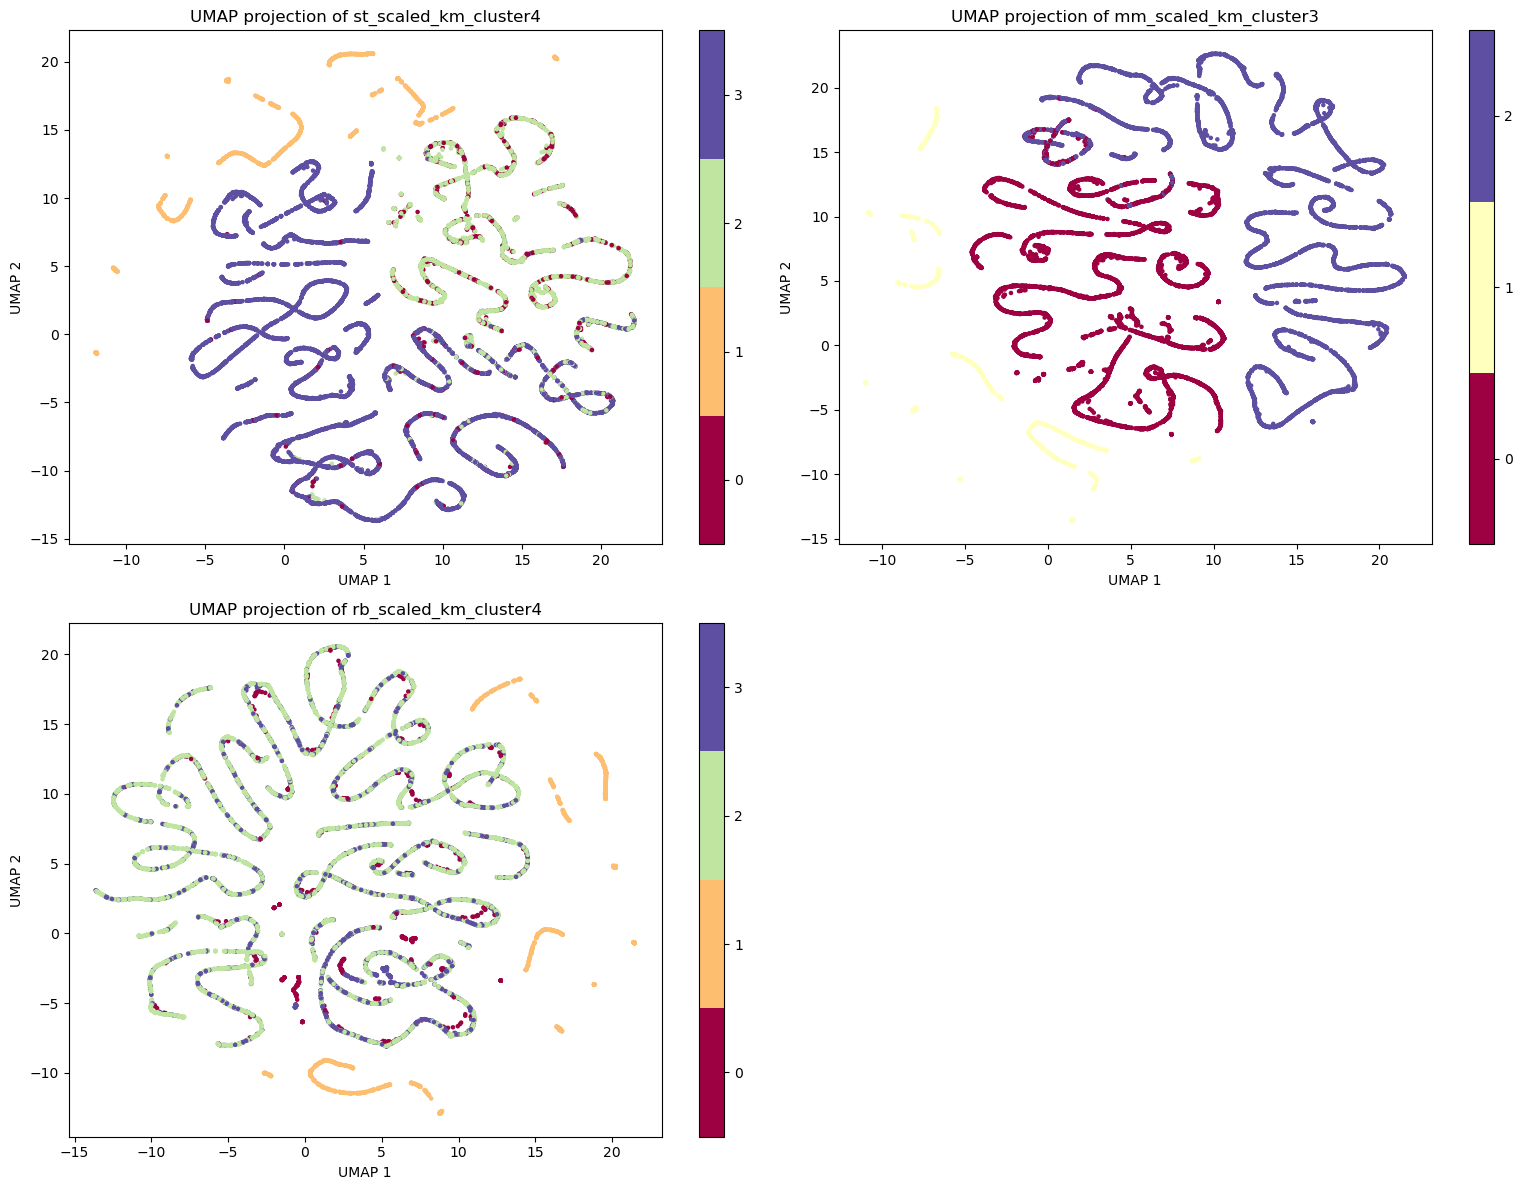

In [49]:
plot_umap_projections(eng_umap, clusters_km)

In [50]:
cluster_ward = [
    'st_scaled_ward_cluster3',
    'mm_scaled_ward_cluster3',
    'mm_scaled_ward_cluster4',
    'rb_scaled_ward_cluster4'
]

In [51]:
# Copy engagement data
eng_umap_ward = customer_engagement.copy()

# Attach Ward cluster labels
for c in cluster_ward:
    eng_umap_ward[c] = people[c]


In [52]:
[col for col in eng_umap_ward.columns if "km" in col or "ward" in col]

['st_scaled_ward_cluster3',
 'mm_scaled_ward_cluster3',
 'mm_scaled_ward_cluster4',
 'rb_scaled_ward_cluster4']

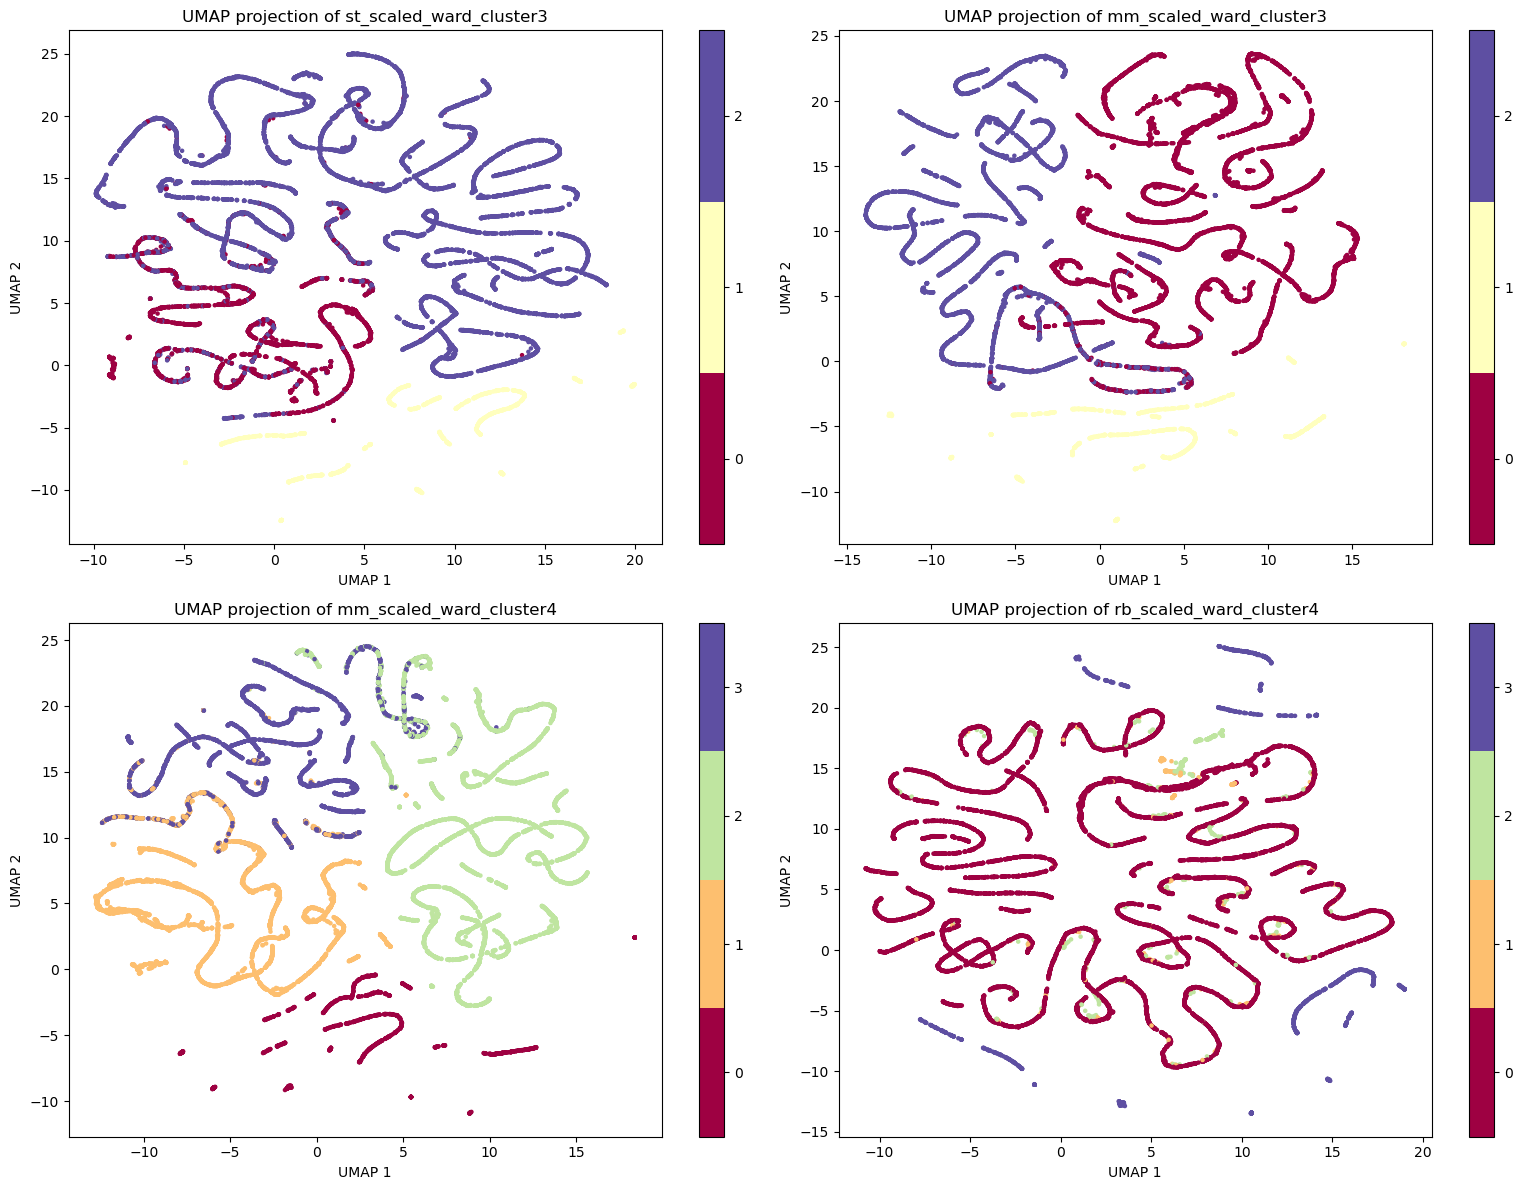

In [53]:
plot_umap_projections(eng_umap_ward, cluster_ward)

In [54]:
candidates = [
    'mm_scaled_km_cluster3',
    'mm_scaled_ward_cluster3',
    'mm_scaled_ward_cluster4',
    'rb_scaled_km_cluster4'
]

for c in candidates:
    tmp = customer_engagement.copy()
    tmp[c] = people[c]

    print(f"\n>>> Cluster profile for: {c}")
    display(
        groupby_mean(
            tmp,
            c,
            n_features=5
        )
    )



>>> Cluster profile for: mm_scaled_km_cluster3


mm_scaled_km_cluster3,0,1,2
Days_in_prog,515.498687,582.224786,1773.980037
RecencyInMonths,2.734683,999.000000,1.753213
Flights_per_day,0.109974,0.001990,0.179607
PctFlightsWithCompanions,0.257701,0.003088,0.250570
PctPointsSpent,0.309738,0.002836,0.300354



>>> Cluster profile for: mm_scaled_ward_cluster3


mm_scaled_ward_cluster3,0,1,2
Days_in_prog,648.797908,582.224786,1918.219983
RecencyInMonths,2.567342,999.000000,1.740257
Flights_per_day,0.122819,0.001990,0.178999
PctFlightsWithCompanions,0.255000,0.003088,0.252808
PctPointsSpent,0.307952,0.002836,0.300522



>>> Cluster profile for: mm_scaled_ward_cluster4


mm_scaled_ward_cluster4,0,1,2,3
Days_in_prog,582.224786,332.294720,1918.219983,1031.588039
RecencyInMonths,999.000000,3.158974,1.740257,1.851801
Flights_per_day,0.001990,0.076978,0.178999,0.178260
PctFlightsWithCompanions,0.003088,0.260516,0.252808,0.248330
PctPointsSpent,0.002836,0.313223,0.300522,0.301577



>>> Cluster profile for: rb_scaled_km_cluster4


rb_scaled_km_cluster4,0,1,2,3
Days_in_prog,649.327611,582.224786,1229.073959,1013.454199
RecencyInMonths,16.637340,999.000000,1.096782,2.660754
Flights_per_day,0.073177,0.001990,0.156026,0.128816
PctFlightsWithCompanions,0.262569,0.003088,0.270032,0.213911
PctPointsSpent,0.293681,0.002836,0.338740,0.224614


In [55]:
#groupby_mean(people, 'rb_scaled_ward_cluster4')

Choosing the model for the next step (Engagement perspective)

We compared four candidate solutions (K-Means and Ward):

* `mm_scaled_km_cluster3`
* `mm_scaled_ward_cluster3`
* `mm_scaled_ward_cluster4`
* `rb_scaled_km_cluster4`

Looking at the cluster profiles, all models revealed the same structure:
a very clear **inactive segment** (almost no flights, no points spent, very high recency).

The **Min-Max + Ward (K = 4)** solution captured this group most cleanly while still
keeping the remaining clusters interpretable.

We continue with **Ward (Min-Max), K = 4**,
and remove the inactive cluster to analyze the rest of the data in the next stage.

#### Cluster Extraction 1

Cluster Extraction — Removing Non-Travelers

From the **Ward clustering (Min-Max, (K = 4))**, one cluster showed a very clear profile:

* **almost no flights**
* **almost no points accumulation or redemption**
* **very high recency** (they haven’t flown in a long time)

These customers are formally enrolled in the loyalty program —
but they **do not actively use it**.

Since the goal of the next analysis is to understand **engaged / traveling members**,
we remove this **inactive segment** and continue with the remaining clusters only.

In [56]:
eng = customer_engagement.copy()
eng['mm_scaled_ward_cluster4'] = people['mm_scaled_ward_cluster4']

In [57]:
inactive_cluster = 0   # Cluster representing inactive customers
non_travelers = eng[eng['mm_scaled_ward_cluster4'] == inactive_cluster]

In [58]:
eng_filtered = eng[eng['mm_scaled_ward_cluster4'] != inactive_cluster]

In [59]:
print(non_travelers.shape)
print(eng_filtered.shape)

(1517, 6)
(15178, 6)


In [60]:
eng_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15178 entries, 100018 to 999986
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              15178 non-null  float64
 1   RecencyInMonths           15178 non-null  float64
 2   Flights_per_day           15178 non-null  float64
 3   PctFlightsWithCompanions  15178 non-null  float64
 4   PctPointsSpent            15178 non-null  float64
 5   mm_scaled_ward_cluster4   15178 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 830.0 KB


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

#### Second Examination — Re-clustering After Removing Non-Travelers

After isolating and removing the *Non-Travelers* segment, we now focus only on customers who actively engage with the program.

Although these customers all travel, they still show different levels and styles of engagement.
To uncover these differences, we run a **second round of clustering** on the filtered dataset.

We continue our analysis using:

```python
eng_filtered
```

This dataset contains:

* only the engagement features
* only active customers (non-travelers removed)

Next, we re-scale and re-cluster this subset to reveal more refined behavioral segments.

In [61]:
eng_filtered.columns

Index(['Days_in_prog', 'RecencyInMonths', 'Flights_per_day',
       'PctFlightsWithCompanions', 'PctPointsSpent',
       'mm_scaled_ward_cluster4'],
      dtype='object')

#### Scaling the Data for Clustering

Clustering algorithms such as K-Means and hierarchical clustering are
distance-based, meaning that variables with larger numeric ranges can dominate
the result. To avoid this, we rescale the features.

At this stage we have already removed the *non-travelers*, and the remaining
customers differ more subtly in their behavior. Because of this, we avoid
Min-Max scaling (which can compress most observations when outliers exist) and
instead use:

* **StandardScaler** – centers features at 0 and scales to unit variance
* **RobustScaler** – similar, but less sensitive to remaining outliers

Using both allows us to compare results and ensure that our conclusions do not
depend on a single scaling choice.

In [62]:
# Standard & Robust scaling after removing non-travellers
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

eng_filtered_st = st_scaler.fit_transform(eng_filtered[engagement_features])
eng_filtered_rb = rb_scaler.fit_transform(eng_filtered[engagement_features])


#### Cluster Modelling 2


**Cluster evaluation — Standard Scaled features**

After removing non-travelers, the inertia curve still shows most of the improvement before (K = 3–4).
The silhouette score peaks at (K = 2), remains reasonable at (K = 3), and declines afterwards.

This suggests that the useful candidates are mainly:

* (K = 2) — coarse split
* (K = 3) — clearer behavioural gradients
* (K = 4) — more detail without over-fragmenting

Larger values of (K) bring little additional structure and risk producing redundant clusters.

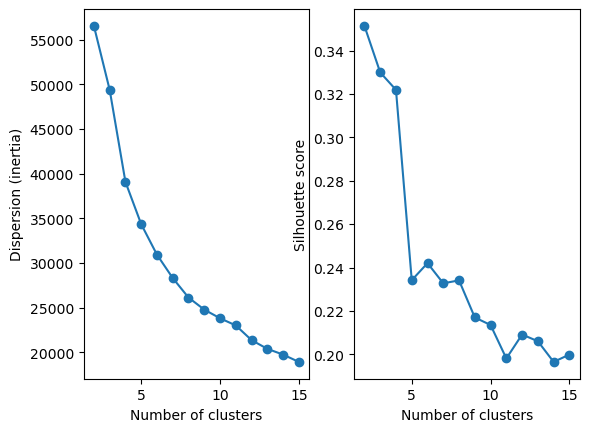

In [63]:
plot_inertia_and_silhouette(eng_filtered_st)

In [64]:
# K-Means (segunda ronda) — Standard Scaler
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42)
    eng_filtered[f'st2_km_cluster{k}'] = model.fit_predict(eng_filtered_st)

In [65]:
for k in [2, 3, 4]:
    tmp = eng_filtered.copy()
    tmp[f'st2_km_cluster{k}'] = eng_filtered[f'st2_km_cluster{k}']

    print(f"\nK-Means (Standard) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st2_km_cluster{k}',
            n_features=5
        )
    )



K-Means (Standard) — k = 2


st2_km_cluster2,0,1
Days_in_prog,1496.976592,375.917865
RecencyInMonths,1.501593,3.855563
Flights_per_day,0.181061,0.065935
PctFlightsWithCompanions,0.249269,0.264705
PctPointsSpent,0.299282,0.317569
mm_scaled_ward_cluster4,2.331471,1.099437



K-Means (Standard) — k = 3


st2_km_cluster3,0,1,2
Days_in_prog,1530.939916,358.670889,637.871387
RecencyInMonths,1.501948,1.673215,16.698347
Flights_per_day,0.182271,0.072453,0.071803
PctFlightsWithCompanions,0.248773,0.264708,0.263036
PctPointsSpent,0.299197,0.320037,0.292305
mm_scaled_ward_cluster4,2.360004,1.094889,1.420520



K-Means (Standard) — k = 4


st2_km_cluster4,0,1,2,3
Days_in_prog,1561.778660,522.873857,638.968070,379.589532
RecencyInMonths,1.494426,1.759568,16.691285,1.639987
Flights_per_day,0.183711,0.082792,0.072277,0.080772
PctFlightsWithCompanions,0.247357,0.405324,0.262706,0.198332
PctPointsSpent,0.288959,0.743894,0.281807,0.142760
mm_scaled_ward_cluster4,2.355351,1.394272,1.420900,1.164069


#### Choosing (K) — Second Round (Standard Scaled)

After removing non-travelers, we re-applied K-Means on the remaining customers.

* **K = 2** produces only a coarse split (high vs. lower engagement), losing nuance.
* **K = 4** starts to fragment clusters into groups that are very similar and harder to interpret.
* **K = 3** provides the most meaningful structure:

  * one cluster with **very long tenure and higher activity**,
  * one cluster with **moderate tenure and regular usage**,
  * one cluster with **high recency (returning customers)**.

This balance between interpretability and separation makes **K = 3** the preferred solution for the second stage.

#### Cluster evaluation — Robust Scaled features

We repeated the evaluation using **robust-scaled features**, which down-weight the effect of outliers.

* Inertia decreases smoothly with no sharp elbow.
* Silhouette is highest at **K = 2**, and then drops and stabilizes at lower values.

This indicates that:

* **K = 2 and K = 3** capture most of the structure,
* larger values mainly fragment clusters without improving separation.

We keep both values as candidates and compare them using cluster profiles and UMAP visualisation.

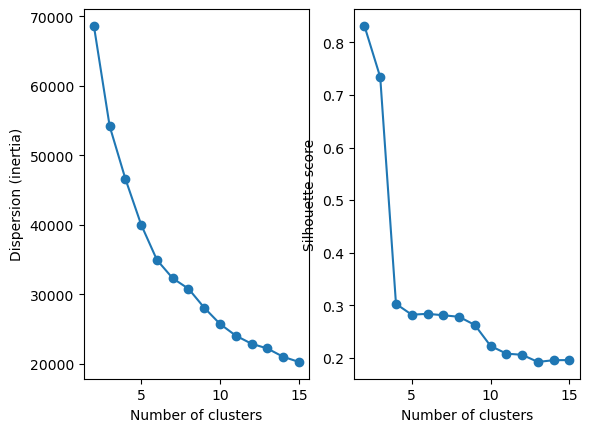

In [66]:
plot_inertia_and_silhouette(eng_filtered_rb)

In [67]:
# K-Means (segunda ronda) — Robust Scaler
for k in [2, 3]:
    model = KMeans(n_clusters=k, random_state=42)
    eng_filtered[f'rb2_km_cluster{k}'] = model.fit_predict(eng_filtered_rb)


In [68]:
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'rb2_km_cluster{k}'] = eng_filtered[f'rb2_km_cluster{k}']

    print(f"\nK-Means (Robust) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb2_km_cluster{k}',
            n_features=5
        )
    )



K-Means (Robust) — k = 2


rb2_km_cluster2,0,1
Days_in_prog,1168.242204,649.274064
RecencyInMonths,1.525364,16.139271
Flights_per_day,0.148308,0.074610
PctFlightsWithCompanions,0.253769,0.261450
PctPointsSpent,0.305644,0.293820
mm_scaled_ward_cluster4,1.968746,1.427807



K-Means (Robust) — k = 3


rb2_km_cluster3,0,1,2
Days_in_prog,1172.461393,627.990805,727.456612
RecencyInMonths,1.460276,19.419850,9.945184
Flights_per_day,0.148850,0.056932,0.100569
PctFlightsWithCompanions,0.253708,0.267929,0.254704
PctPointsSpent,0.305821,0.289676,0.296517
mm_scaled_ward_cluster4,1.972228,1.372414,1.566116


#### Choosing K (second round — robust scaling)

After removing non-travellers, we re-clustered the remaining customers using
Robust-Scaled features.

Comparing (K = 2) and (K = 3):

* **K = 2** clearly separates highly engaged customers from low-engagement ones.
* **K = 3** only splits the low-engagement group into two very similar segments,
  without adding meaningful behavioural differences.

Because it provides a simpler and more interpretable segmentation,
we retain **K = 2 as the preferred solution** for this second step.

#### Ward clustering — second round (after removing non-travellers)

We inspected the Ward dendrogram on the filtered dataset.
Two clear height “jumps” appear:

* the first separation happens around **K = 2**,
* a secondary, meaningful split appears at **K = 3**.

Beyond (K > 3), merges occur at very small distances, suggesting those splits
are minor refinements rather than distinct behavioural groups.

Therefore, we retain **K = 2 and K = 3 as candidates** and compare their
cluster profiles next.

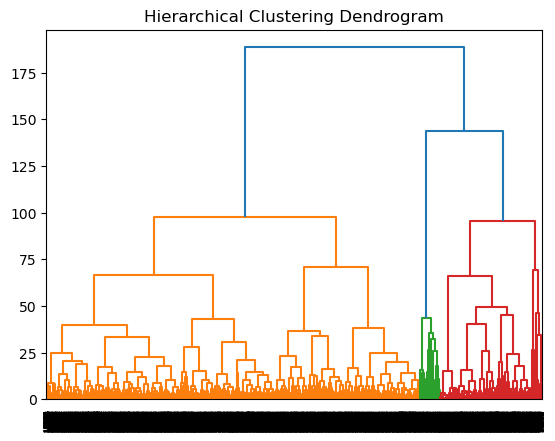

In [69]:
plot_dendrogram(eng_filtered_st, 'ward')

In [70]:
# Ward clustering — filtered engagement data (Standard scaled)
for k in [2, 3]:
    eng_filtered[f'st2_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(eng_filtered_st)


In [71]:
# Inspect cluster profiles (Ward, second round)
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'st2_ward_cluster{k}'] = eng_filtered[f'st2_ward_cluster{k}']

    print(f"\nWard (Standard) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st2_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Standard) — k = 2


st2_ward_cluster2,0,1
Days_in_prog,352.835247,1401.384064
RecencyInMonths,4.505122,1.505423
Flights_per_day,0.052691,0.174806
PctFlightsWithCompanions,0.271455,0.248478
PctPointsSpent,0.341398,0.293159
mm_scaled_ward_cluster4,1.098798,2.218315



Ward (Standard) — k = 3


st2_ward_cluster3,0,1,2
Days_in_prog,1401.384064,285.982120,694.407830
RecencyInMonths,1.505423,1.996222,17.323840
Flights_per_day,0.174806,0.048710,0.073035
PctFlightsWithCompanions,0.248478,0.270491,0.276376
PctPointsSpent,0.293159,0.346392,0.315881
mm_scaled_ward_cluster4,2.218315,1.020434,1.499184


#### Choosing K for Ward clustering (second round)

After removing non-travellers, the Ward solutions became much clearer:

* **K = 2** separates customers mainly by *engagement intensity*
  (low vs. high tenure / flights).
* **K = 3** adds one extra group, but it mostly splits the lower-engagement
  customers into two very similar segments.

The cluster means show that the third group does not introduce a new behavioral
pattern — it simply refines the same low-activity profile.

For interpretability and stability, we therefore keep **K = 2** for the Ward
solution in this round.

#### Ward clustering (Robust-scaled) — choosing K

The Ward dendrogram on the robust-scaled data shows one dominant split:

* **K = 2**: separates customers into clearly distinct groups.
* **K = 3**: introduces one smaller branch, but still along the same
  engagement gradient.

Because the structure is simple and hierarchical, we evaluate **K = 2 and K = 3** as the most reasonable candidates.

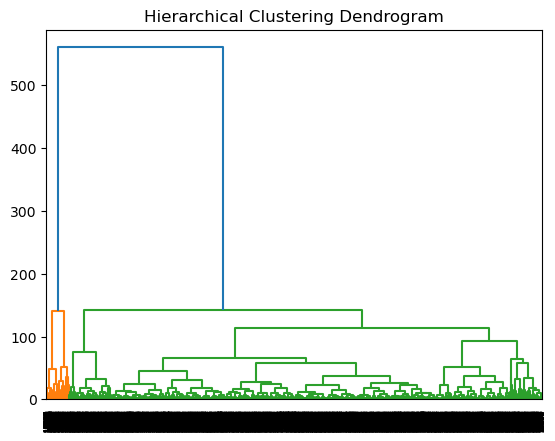

In [72]:
plot_dendrogram(eng_filtered_rb, 'ward')

In [73]:
# Ward clustering — filtered engagement data (Robust scaled)
for k in [2, 3]:
    eng_filtered[f'rb2_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(eng_filtered_rb)


In [74]:
# Inspect cluster profiles (Ward, robust — second round)
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'rb2_ward_cluster{k}'] = eng_filtered[f'rb2_ward_cluster{k}']

    print(f"\nWard (Robust) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb2_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Robust) — k = 2


rb2_ward_cluster2,0,1
Days_in_prog,1166.665584,647.779202
RecencyInMonths,1.549225,16.604848
Flights_per_day,0.148141,0.073223
PctFlightsWithCompanions,0.253764,0.262051
PctPointsSpent,0.305601,0.293938
mm_scaled_ward_cluster4,1.967118,1.425926



Ward (Robust) — k = 3


rb2_ward_cluster3,0,1,2
Days_in_prog,647.779202,1164.462711,1189.087259
RecencyInMonths,16.604848,1.292778,4.159433
Flights_per_day,0.073223,0.148311,0.146409
PctFlightsWithCompanions,0.262051,0.254499,0.246284
PctPointsSpent,0.293938,0.310877,0.251901
mm_scaled_ward_cluster4,1.425926,1.962370,2.015444


#### Ward (Robust) — choosing the final K

After re-clustering the filtered dataset with Ward (robust-scaled), we compared:

* **K = 2** — a clean split between

  * long-tenure, high-activity customers
  * shorter-tenure, lower-activity customers.

* **K = 3** — introduces a third group, but it mainly splits the
  higher-engagement segment into two very similar sub-clusters,
  without adding clear business meaning.

Because **K = 2** preserves the main behavioral separation while keeping the solution simple and interpretable,
we retain **Ward (Robust) with K = 2** for this stage.

#### Cluster Visualization 2

#### Cluster Visualisation — Round 2 (after removing Non-Travelers)

With the inactive customers removed, we re-clustered the remaining base and
focused only on the most meaningful solutions identified earlier:

* **K-Means (Standard scaled)**: (K = 3)
* **K-Means (Robust scaled)**: (K = 2)
* **Ward hierarchical (Standard)**: (K = 2)
* **Ward hierarchical (Robust)**: (K = 2)

These values come from the inertia/silhouette diagnostics and dendrogram
structure: they capture the main engagement differences without creating
unnecessary small clusters.

We now project these models into **2D with UMAP**.
UMAP does *not* influence clustering — it simply helps us see whether the
segments form compact, well-separated groups and whether the different methods
are telling a consistent behavioural story.

In [75]:
cluster_filter2 = [
    'st2_km_cluster3',
    'rb2_km_cluster2',
    'st2_ward_cluster2',
    'rb2_ward_cluster2'
]

In [76]:
eng_umap2 = eng_filtered.copy()

for c in cluster_filter2:
    eng_umap2[c] = eng_filtered[c]


cols_to_keep = engagement_features + cluster_filter2
eng_umap2 = eng_umap2[cols_to_keep]


In [77]:
[col for col in eng_umap2.columns if "km" in col or "ward" in col]

['st2_km_cluster3',
 'rb2_km_cluster2',
 'st2_ward_cluster2',
 'rb2_ward_cluster2']

In [78]:
[col for col in eng_umap2.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st2_km_cluster3',
 'rb2_km_cluster2',
 'st2_ward_cluster2',
 'rb2_ward_cluster2']

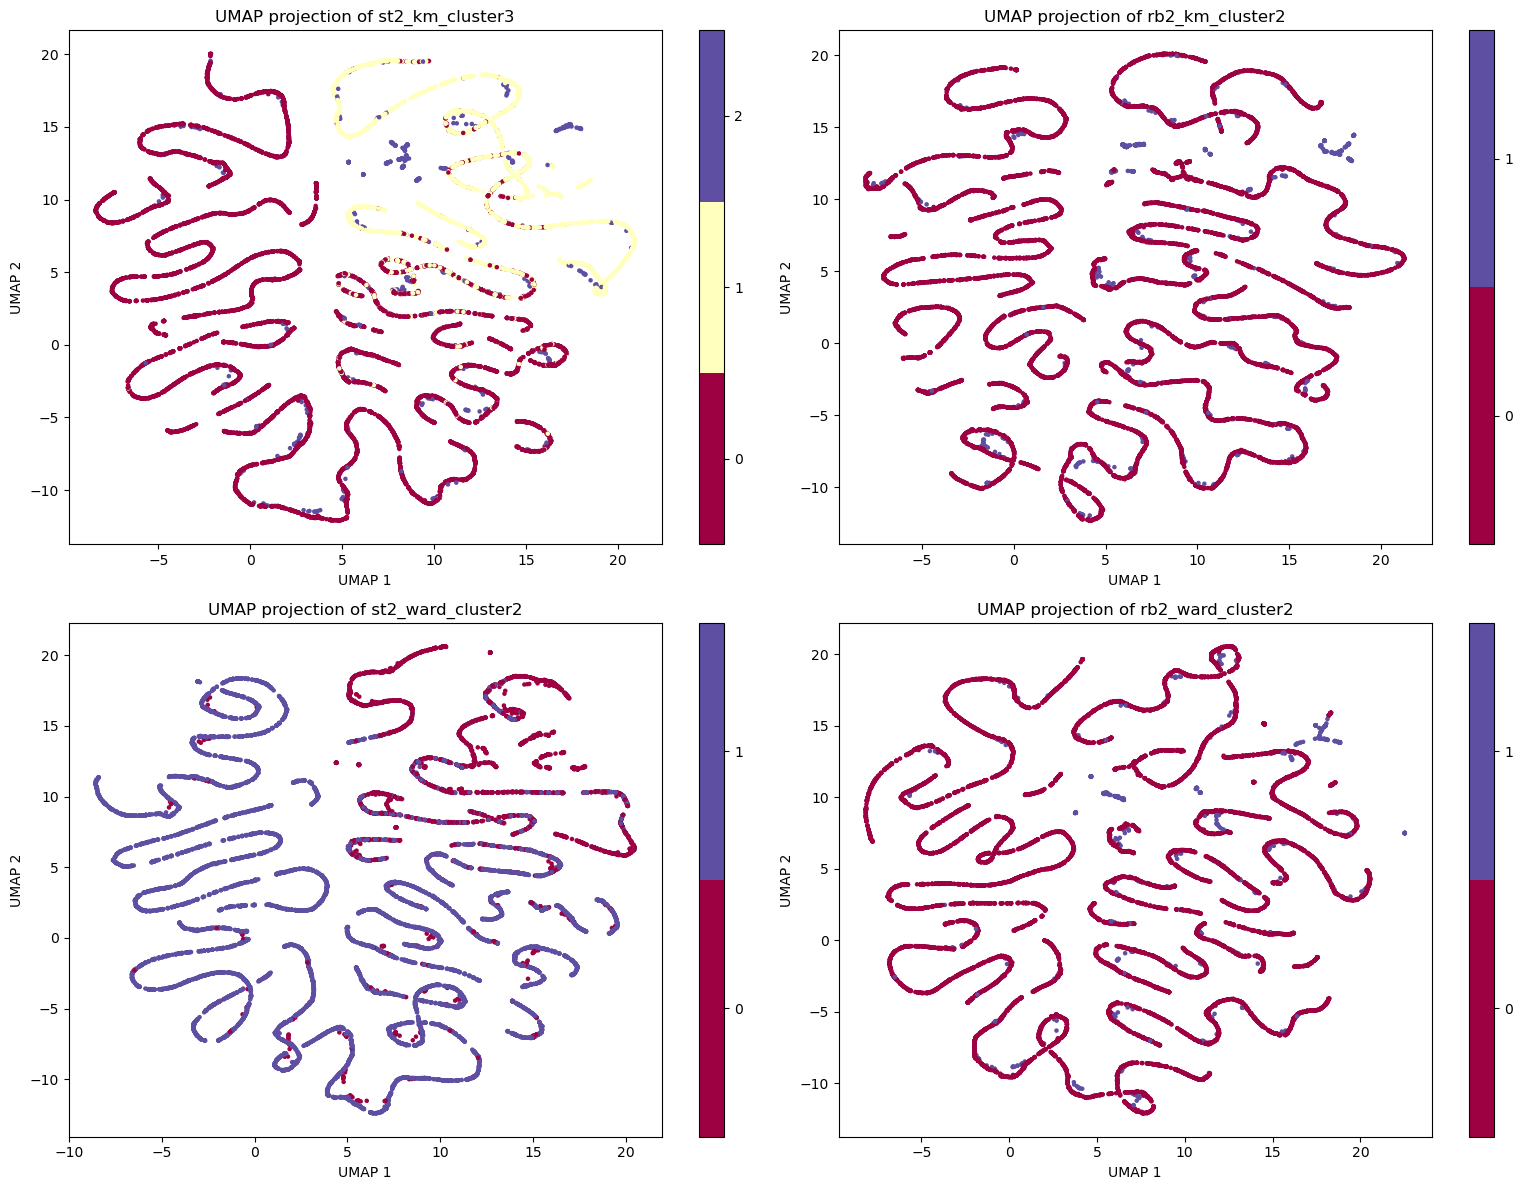

In [79]:
plot_umap_projections(eng_umap2, cluster_filter2)

In [80]:
for c in ['st2_km_cluster3', 'st2_ward_cluster2']:
    tmp = eng_filtered.copy()
    print(f"\n>>> {c}")
    display(groupby_mean(tmp, c, n_features=5))



>>> st2_km_cluster3


st2_km_cluster3,0,1,2
Days_in_prog,1530.939916,358.670889,637.871387
RecencyInMonths,1.501948,1.673215,16.698347
Flights_per_day,0.182271,0.072453,0.071803
PctFlightsWithCompanions,0.248773,0.264708,0.263036
PctPointsSpent,0.299197,0.320037,0.292305
mm_scaled_ward_cluster4,2.360004,1.094889,1.420520



>>> st2_ward_cluster2


st2_ward_cluster2,0,1
Days_in_prog,352.835247,1401.384064
RecencyInMonths,4.505122,1.505423
Flights_per_day,0.052691,0.174806
PctFlightsWithCompanions,0.271455,0.248478
PctPointsSpent,0.341398,0.293159
mm_scaled_ward_cluster4,1.098798,2.218315


Interpreting the 3-cluster KM solution

The 3-cluster K-Means model revealed one segment with a very distinct profile:

very old program tenure

few flights recently

still uses points occasionally

This group behaves like dormant travelers: customers who used to be active,
but whose current engagement is low.

The remaining clusters showed more typical travelling patterns, with higher and
more regular activity levels.

This confirms that the 3-cluster solution provides a meaningful separation
between active travelers and dormant travelers, which is useful for the
next refinement step.

#### Cluster Extraction — Step 2 (removing dormant travelers)

From the 3-cluster K-Means model on the filtered base,
Cluster **2** corresponded to **dormant travelers**:

* long historical relationship with the program
* low current flight frequency
* moderate points usage

Since our next objective is to study **active travelers only**, we:

1. isolated this cluster as `dormant_travelers`, and
2. created a new dataset `eng_round3` excluding them.

This allows the following round of clustering to focus purely on **currently
engaged customers**, revealing more granular behavioural patterns inside that
group.

In [81]:
cluster_to_remove = 2
eng_filtered2 = eng_filtered[eng_filtered['st2_km_cluster3'] != cluster_to_remove]

In [82]:
dormant_travelers = eng_filtered[eng_filtered['st2_km_cluster3'] == cluster_to_remove]

In [83]:
print(dormant_travelers.shape)
print(eng_filtered2.shape)

(692, 15)
(14486, 15)


In [84]:
eng_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14486 entries, 100018 to 999986
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              14486 non-null  float64
 1   RecencyInMonths           14486 non-null  float64
 2   Flights_per_day           14486 non-null  float64
 3   PctFlightsWithCompanions  14486 non-null  float64
 4   PctPointsSpent            14486 non-null  float64
 5   mm_scaled_ward_cluster4   14486 non-null  int64  
 6   st2_km_cluster2           14486 non-null  int32  
 7   st2_km_cluster3           14486 non-null  int32  
 8   st2_km_cluster4           14486 non-null  int32  
 9   rb2_km_cluster2           14486 non-null  int32  
 10  rb2_km_cluster3           14486 non-null  int32  
 11  st2_ward_cluster2         14486 non-null  int64  
 12  st2_ward_cluster3         14486 non-null  int64  
 13  rb2_ward_cluster2         14486 non-null  int64  
 14  rb2_w

In [85]:
eng_round3 = eng_filtered2[engagement_features].copy()

In [86]:
[col for col in eng_round3.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent']

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

#### Re-Scaling Data 3

In [87]:
eng_round3

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,874.0,1.018397,0.209954,0.213136,0.387873
100102,2122.0,1.018397,0.226210,0.234154,0.553345
100140,884.0,2.003942,0.197991,0.249077,0.113353
100214,1242.0,1.018397,0.102557,0.178094,0.354109
100272,1816.0,2.003942,0.170228,0.284335,0.253564
...,...,...,...,...,...
999758,131.0,1.018397,0.014612,0.250000,0.682669
999902,1681.0,3.022339,0.243927,0.284538,0.172142
999940,523.0,1.018397,0.079909,0.320000,0.235584


In [88]:
eng_round3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14486 entries, 100018 to 999986
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              14486 non-null  float64
 1   RecencyInMonths           14486 non-null  float64
 2   Flights_per_day           14486 non-null  float64
 3   PctFlightsWithCompanions  14486 non-null  float64
 4   PctPointsSpent            14486 non-null  float64
dtypes: float64(5)
memory usage: 679.0 KB


In [89]:
# Standard & Robust scaling — Round 3
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

eng_round3_st = st_scaler.fit_transform(eng_round3)
eng_round3_rb = rb_scaler.fit_transform(eng_round3)


In [90]:
eng_round3_st.head()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,-0.407012,-0.487956,0.946735,-0.361436,0.246015
100102,1.327908,-0.487956,1.195772,-0.174264,0.741244
100140,-0.393111,0.407989,0.763456,-0.041369,-0.575572
100214,0.104567,-0.487956,-0.698583,-0.673492,0.144966
100272,0.902519,0.407989,0.338135,0.272607,-0.155946


In [91]:
eng_round3_rb.head()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,-0.201903,0.0,0.603624,-0.264127,0.385147
100102,0.767230,0.0,0.805210,-0.095816,0.848239
100140,-0.194137,1.0,0.455266,0.023688,-0.383127
100214,0.083867,0.0,-0.728199,-0.544739,0.290655
100272,0.529606,1.0,0.110985,0.306025,0.009269


#### Cluster Modelling 3

Using the **standard-scaled dataset**:

* **Inertia** decreases smoothly with no clear elbow.
* **Silhouette scores** drop noticeably after **K = 2** and remain relatively low afterward.

This suggests that small values of **K (around 2–3)** capture most of the meaningful structure, while larger K mainly add complexity without clear separation benefits.

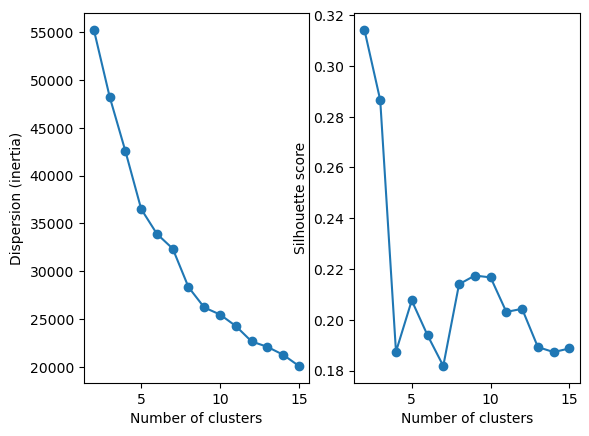

In [92]:
plot_inertia_and_silhouette(eng_round3_st)

#### Cluster evaluation — Robust Scaled (Round 3)

With the **robust-scaled features**:

* **Inertia** again declines gradually.
* **Silhouette** is highest at **K = 2** and steadily worsens as K increases.

Here, **K = 2 clearly stands out** as the most stable and interpretable solution.

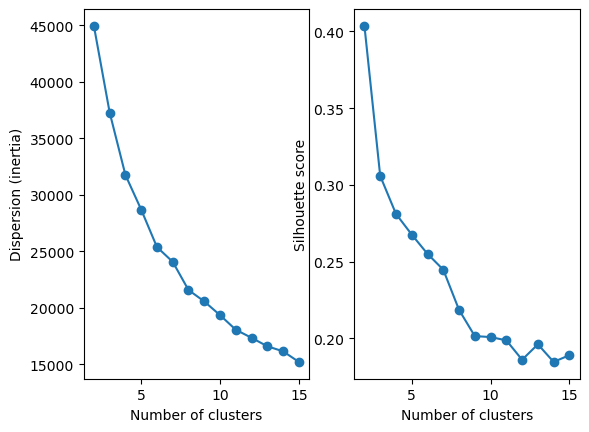

In [93]:
plot_inertia_and_silhouette(eng_round3_rb)

#### Dendrogram — Standard Scaled (Ward linkage)

The Ward dendrogram on the standard-scaled data shows:

* One dominant split forming **two major branches**.
* Additional cuts (K ≥ 3) start fragmenting the tree into smaller, less meaningful groups.

This supports **K ≈ 2** as the most natural hierarchical cut.

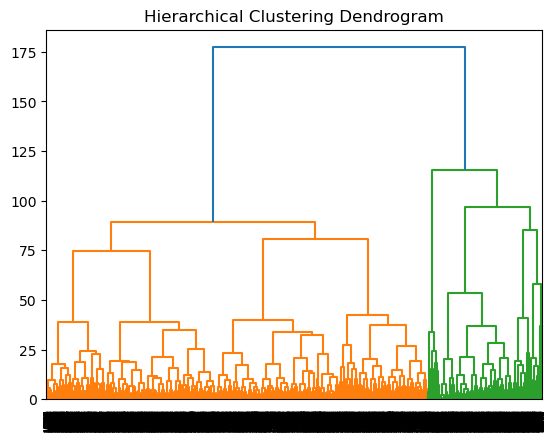

In [94]:
plot_dendrogram(eng_round3_st, 'ward')

#### Dendrogram — Robust Scaled (Ward linkage)

For the robust-scaled dendrogram:

* A strong top-level division again appears at **two clusters**.
* Further splits tend to produce unbalanced or noisy sub-groups.

Once more, **K = 2** emerges as the most interpretable segmentation level.

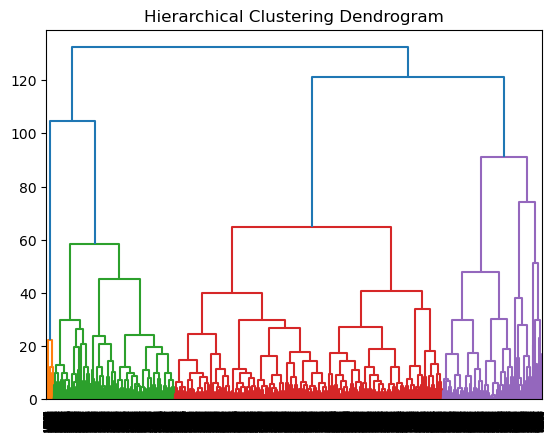

In [95]:
plot_dendrogram(eng_round3_rb, 'ward')

#### Hierarchical clustering (refinement step)

We now re-apply hierarchical clustering — but only on the customers who remain
after removing:

1. Non-travelers (Round 1)
2. Dormant / very low-activity travelers (Round 2)

The diagnostics for this round were very consistent:

* Both **standard-scaled** and **robust-scaled** dendrograms show a clear
  dominant split into **two main groups**.
* Silhouette curves confirm that increasing K beyond 2 does **not** create
  better-separated clusters.

At this stage, choosing **small K values is intentional**.
We are refining the segmentation step-by-step, uncovering structure gradually
instead of forcing many artificial micro-clusters all at once.

Therefore, we proceed with:

* **Ward (Standard)** → K = 2
* **Ward (Robust)** → K = 2

and compare the resulting segment profiles.

In [96]:
# Ward clustering — Round 3 (Standard & Robust)
eng_round3['st3_ward_cluster2'] = AgglomerativeClustering(
    linkage='ward',
    n_clusters=2
).fit_predict(eng_round3_st)

eng_round3['rb3_ward_cluster2'] = AgglomerativeClustering(
    linkage='ward',
    n_clusters=2
).fit_predict(eng_round3_rb)


In [97]:
# Inspect cluster profiles — Ward (Round 3)
for label in ['st3_ward_cluster2', 'rb3_ward_cluster2']:
    
    tmp = eng_round3.copy()
    tmp[label] = eng_round3[label]

    print(f"\nWard — {label}")
    display(
        groupby_mean(
            tmp,
            label,
            n_features=5
        )
    )



Ward — st3_ward_cluster2


st3_ward_cluster2,0,1
Days_in_prog,324.733133,1418.617164
RecencyInMonths,1.937037,1.440938
Flights_per_day,0.053104,0.176585
PctFlightsWithCompanions,0.264365,0.250540
PctPointsSpent,0.329315,0.298599
rb3_ward_cluster2,0.169715,0.286342



Ward — rb3_ward_cluster2


rb3_ward_cluster2,0,1
Days_in_prog,1109.183649,1331.144453
RecencyInMonths,1.106827,2.834529
Flights_per_day,0.143937,0.160199
PctFlightsWithCompanions,0.252562,0.257036
PctPointsSpent,0.303707,0.311276
st3_ward_cluster2,0.741866,0.849428


#### K-Means refinement (visual validation)

Next, we also apply K-Means on the refined dataset to see whether a simpler
partition emerges consistently across algorithms

In [98]:
# K-Means — Round 3 (Standard & Robust)
kmeans_st3 = KMeans(n_clusters=2, random_state=42).fit(eng_round3_st)
eng_round3['st3_km_cluster2'] = kmeans_st3.predict(eng_round3_st)

kmeans_rb3 = KMeans(n_clusters=2, random_state=42).fit(eng_round3_rb)
eng_round3['rb3_km_cluster2'] = kmeans_rb3.predict(eng_round3_rb)


In [99]:
# Inspect cluster profiles — K-Means (Round 3)
for label in ['st3_km_cluster2', 'rb3_km_cluster2']:
    
    tmp = eng_round3.copy()
    tmp[label] = eng_round3[label]

    print(f"\nK-Means — {label}")
    display(
        groupby_mean(
            tmp,
            label,
            n_features=5
        )
    )


K-Means — st3_km_cluster2


st3_km_cluster2,0,1
Days_in_prog,368.961073,1531.775732
RecencyInMonths,1.748312,1.466782
Flights_per_day,0.073078,0.182505
PctFlightsWithCompanions,0.264948,0.248588
PctPointsSpent,0.319378,0.299400
st3_ward_cluster2,0.281944,0.992957



K-Means — rb3_km_cluster2


rb3_km_cluster2,0,1
Days_in_prog,1175.618240,1097.318043
RecencyInMonths,1.242946,4.009070
Flights_per_day,0.150041,0.133345
PctFlightsWithCompanions,0.253379,0.256422
PctPointsSpent,0.303725,0.320964
st3_ward_cluster2,0.786787,0.636086


In [100]:
cluster_filter3 = [
    'st3_km_cluster2',
    'rb3_km_cluster2',
    'st3_ward_cluster2',
    'rb3_ward_cluster2'
]


In [101]:
eng_umap3 = eng_round3.copy()

for c in cluster_filter3:
    eng_umap3[c] = eng_round3[c]

# Keep only engagement features + these clusters
cols_to_keep = engagement_features + cluster_filter3
eng_umap3 = eng_umap3[cols_to_keep]


In [102]:
[col for col in eng_umap3.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st3_km_cluster2',
 'rb3_km_cluster2',
 'st3_ward_cluster2',
 'rb3_ward_cluster2']

We then project all clustering solutions into UMAP space to visually compare
their separation:

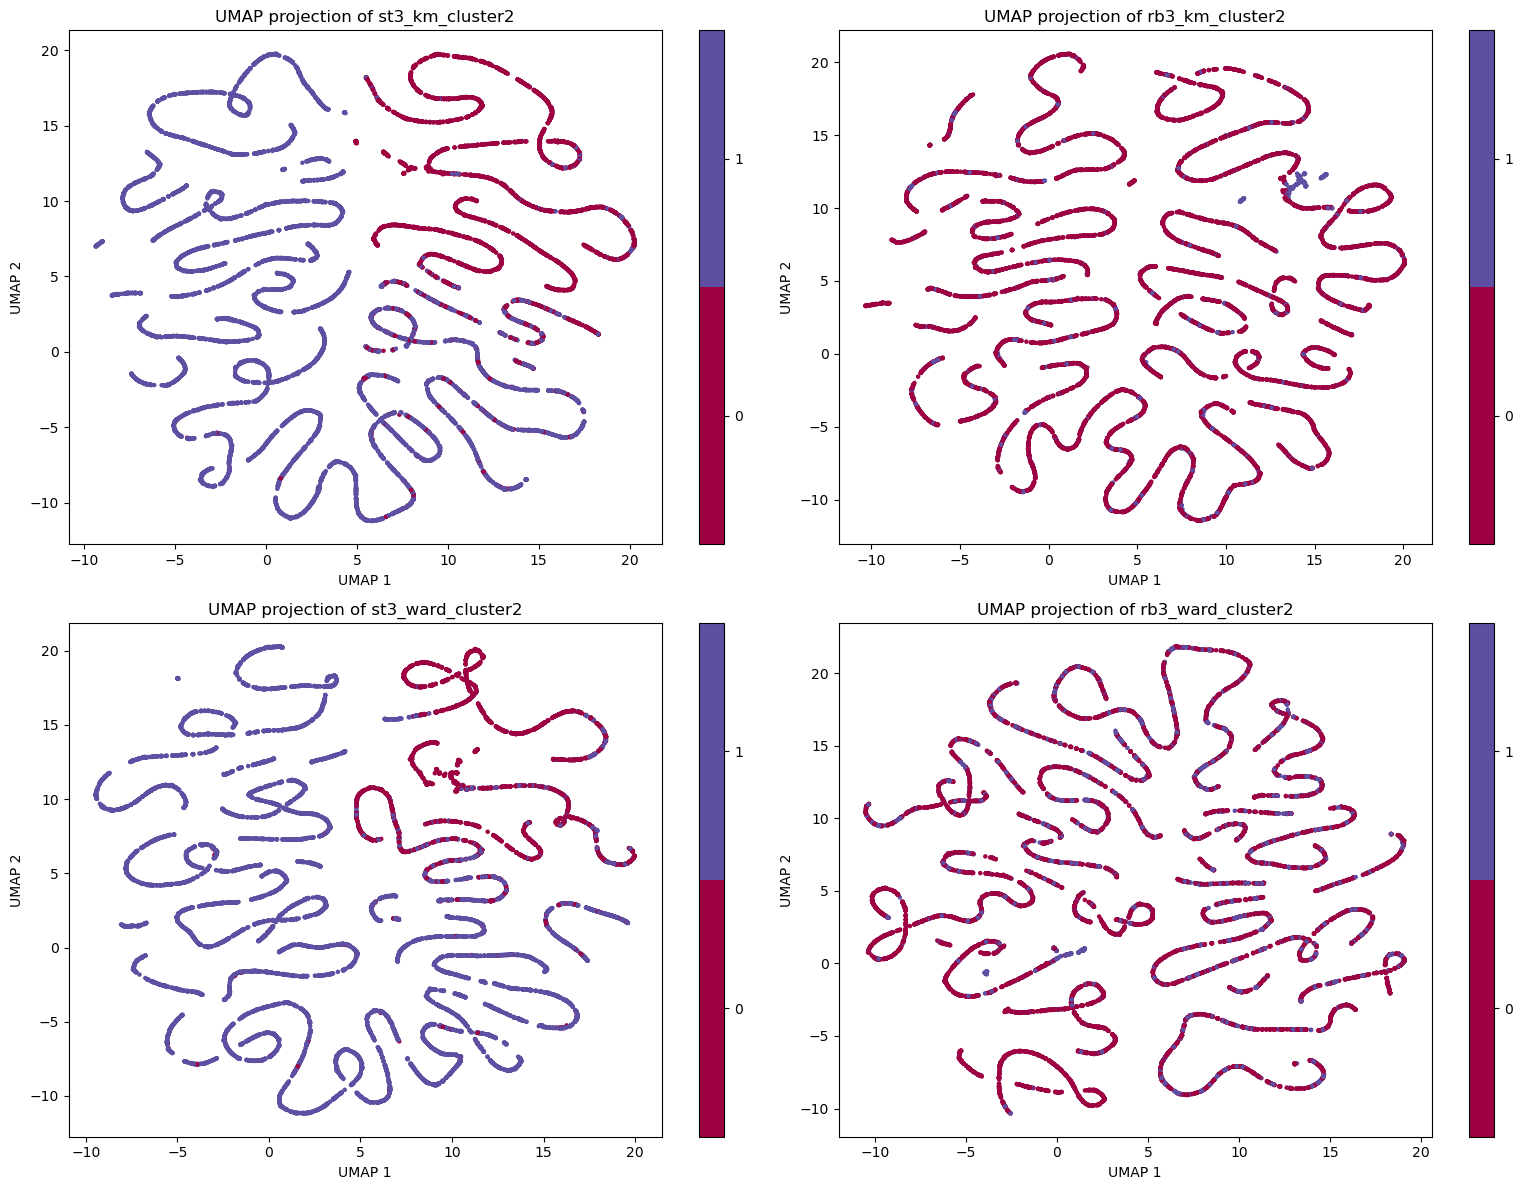

In [103]:
plot_umap_projections(eng_umap3, cluster_filter3)

We selected the Standard-scaled K-Means (K = 2) model.
Among all candidates, it produced the cleanest UMAP separation and the clearest
behavioural contrast in the cluster means.

* **Cluster 0**

  * much shorter program tenure
  * much lower flight frequency
  * still spend occasionally, but irregular
* **Cluster 1**

  * long tenure
  * regular flight activity
  * consistently using points

##### Cluster Interpretation — Round 3 (K-Means, Standard)

The chosen 2-cluster solution reveals a final, meaningful split:

* **Cluster 1 — “Active Regular Travelers”**
  Customers who remain consistently engaged: longer tenure, frequent flying,
  and steady points redemption.

* **Cluster 0 — “Low-Engagement / Light Users”**
  Customers who fly occasionally, participate less, and show weaker loyalty
  signals.

This final refinement helps distinguish customers who are still committed to
the program from those whose participation remains marginal.

#### Cluster Extraction 3

In [104]:
# Final split
low_engagement = eng_round3[eng_round3['st3_km_cluster2'] == 0]
active_travelers = eng_round3[eng_round3['st3_km_cluster2'] == 1]

# Remove both -> nothing left to cluster
eng_final = eng_round3[~eng_round3['st3_km_cluster2'].isin([0, 1])]

eng_final.shape


(0, 9)

In [105]:
people['segment'] = 'Unassigned'

people.loc[non_travelers.index, 'segment'] = 'Non_Travelers'
people.loc[active_travelers.index, 'segment'] = 'Active_Travelers'
people.loc[dormant_travelers.index, 'segment'] = 'Dormant_Travelers'
people.loc[low_engagement.index, 'segment'] = 'Low_Engagement'


The result (eng_final) is empty, meaning that all remaining customers
were already classified into meaningful segments at this stage.
No additional clustering is necessary for this branch.

In [106]:
eng_final

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent,st3_ward_cluster2,rb3_ward_cluster2,st3_km_cluster2,rb3_km_cluster2
Loyalty#,,,,,,,,,


In [107]:
people['segment'].value_counts()

segment
Active_Travelers     9939
Low_Engagement       4547
Non_Travelers        1517
Dormant_Travelers     692
Name: count, dtype: int64

In [108]:
people['segment'].value_counts().sum()

np.int64(16695)

In [109]:
(people['segment'] == "Unassigned").sum()

np.int64(0)

In [110]:
people[['segment'] + engagement_features].groupby('segment').mean()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
segment,,,,,
Active_Travelers,1531.775732,1.466782,0.182505,0.248588,0.299400
Dormant_Travelers,637.871387,16.698347,0.071803,0.263036,0.292305
Low_Engagement,368.961073,1.748312,0.073078,0.264948,0.319378
Non_Travelers,582.224786,999.000000,0.001990,0.003088,0.002836


# <span style="color:#0097b2">3. Final Customer Segmentation Assignment</span>
[Back to TOC](#toc)

After completing all clustering rounds, each customer is assigned to one of the
final engagement-based segments:

* **Non_Travelers** – customers who are enrolled in the program but never fly.
* **Dormant_Travelers** – previously active customers whose activity has dropped close to zero.
* **Low_Engagement** – occasional travelers with limited and irregular program use.
* **Active_Travelers** – consistently engaged travelers with regular activity and point usage.

We created the segment column and mapped customers to their corresponding group:

Result:

| Segment           | Customers |
| ----------------- | --------: |
| Active_Travelers  |     9,939 |
| Low_Engagement    |     4,547 |
| Non_Travelers     |     1,517 |
| Dormant_Travelers |       692 |

Each customer now belongs to **exactly one** clearly interpretable behavioral group.

This confirms that our segmentation meaningfully splits the population into
distinct groups (loyal, at-risk, inactive and non-travelers).

To make the segment usable in downstream analytics and modeling, we convert the
categorical label into one-hot encoded variables:

In [111]:
segment_dummies = pd.get_dummies(
    people['segment'],
    prefix='seg',
    dtype=int
)

#### Append the Encoded Segments to the Dataset

We now merge the one-hot encoded segment columns back into the main dataset.

This keeps all original features while adding four new binary indicators for the
final customer segments.

In [112]:
people = pd.concat([people, segment_dummies], axis=1)

Since the segment is now represented by one-hot encoded variables, the original
categorical column is no longer needed:

In [113]:
people.drop(columns=['segment'], inplace=True)

In [114]:
people = people.loc[:, ~people.columns.str.startswith(("st_", "mm_", "rb_"))]

#### Appending Encoded Segments

We convert the categorical segment label into one-hot encoded variables and
append them to the main dataset. This preserves all original features while
adding four new binary indicators — one for each final customer segment.

Displaying `people` confirms the final structure: each row now contains
exactly one segment flag equal to 1, and 0 for the others.

**Key added columns:**

* `seg_Active_Travelers`
* `seg_Low_Engagement`
* `seg_Dormant_Travelers`
* `seg_Non_Travelers`

Each customer belongs to exactly **one** segment.

In [115]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,0,0,1,0,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,0,0,1,0,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,0,0,1,0,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,0,0,1,0,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,0,0,1,0,0,0,0,1


In [116]:
people.to_csv('engagement_based_perspective_clusters.csv')

#### Summary

This perspective grouped customers using engagement signals such as:

* program tenure
* flight frequency
* recency of activity
* companion travel
* loyalty points usage

We applied clustering **iteratively**, removing clearly distinct segments at each step.

---

##### Step 1 — Identify Non-Travelers

The first pass revealed a large segment of customers who **never fly**.
They behave structurally differently, so they were isolated as:

**Non_Travelers**

---

##### Step 2 — Remove Dormant Travelers

Among remaining customers, we found a group with **past activity but almost no
recent usage**.

**Dormant_Travelers**

---

##### Step 3 — Final split of active flyers

The last clustering round separated two clear groups:

* **Low_Engagement** – occasional or irregular travelers
* **Active_Travelers** – consistent, frequent program users

After this step, no customers remained unclassified.

---

##### Final Segments

| Segment               | Meaning                                         |
| --------------------- | ----------------------------------------------- |
| **Non_Travelers**     | Enrolled, but never fly or use loyalty benefits |
| **Dormant_Travelers** | Previously active, now inactive                 |
| **Low_Engagement**    | Light / occasional travelers                    |
| **Active_Travelers**  | Regular, highly engaged members                 |

---

##### Why this matters

The segmentation is:

* simple to interpret
* behavior-driven
* stable across methods
* directly actionable

It supports strategies such as:

* onboarding for **Low_Engagement**
* re-activation for **Dormant_Travelers**
* retention programs for **Active_Travelers**
* separate handling of **Non_Travelers**